In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

RANDOM_STATE = 42

## 1. Данные и первичный анализ

In [2]:
df = pd.read_excel('input_data.xlsx')

print(f'Размер таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов')
display(df.head())

print('\n=== Типы данных и пропуски ===')
df.info()
print('Всего пропусков:', int(df.isna().sum().sum()))

print('\n=== Дубликаты и идентификаторы ===')
print('Полностью совпадающих строк:', int(df.duplicated().sum()))
print('Уникальных значений contract_num:', df['contract_num'].nunique(), '(номера замаскированы звёздочками)')

print('\n=== Описательные статистики ===')
display(df.describe().T.round(2))

print('\n=== Категориальные признаки ===')
for col in ['product_name', 'contract_status', 'currency_name', 'sex', 'anomaly']:
    print(df[col].value_counts().to_string(), '\n')
print(df['country'].value_counts().to_string())

print('\n=== Связь валюты и страны ===')
display(pd.crosstab(df['currency_name'], df['country'].eq('США'), rownames=['валюта'], colnames=['страна = США']))

Размер таблицы: 3711 строк, 15 столбцов


,contract_num,product_name,contract_status,currency_name,duration,country,age,sex,price,insurance_amount,loss_payout_amt,price_usd,insurance_amount_usd,loss_payout_amt_usd,anomaly
0,ТТЕ7227715*****,Страхование путешественников,Действует,Российский рубль,10,Беларусь,20,M,1096,2000000,0,12.41768,22660.000080,0.0,1
1,ТТЕ7227715*****,Страхование путешественников,Действует,Российский рубль,7,Индонезия,55,M,1918,5000000,0,21.73094,56650.000199,0.0,-1
2,БАДАМСТЕ55*****,Страхование путешественников,Действует,Российский рубль,10,Беларусь,61,F,1096,2000000,0,12.41768,22660.000080,0.0,-1
3,ТТЕ7227715*****,Страхование путешественников,Действует,Российский рубль,14,Грузия,25,M,1534,2000000,0,17.38022,22660.000080,0.0,1
4,ТТЕ7227715*****,Страхование путешественников,Действует,Российский рубль,7,Аргентина,33,M,1918,5000000,0,21.73094,56650.000199,0.0,-1



=== Типы данных и пропуски ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3711 entries, 0 to 3710
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   contract_num          3711 non-null   object 
 1   product_name          3711 non-null   object 
 2   contract_status       3711 non-null   object 
 3   currency_name         3711 non-null   object 
 4   duration              3711 non-null   int64  
 5   country               3711 non-null   object 
 6   age                   3711 non-null   int64  
 7   sex                   3711 non-null   object 
 8   price                 3711 non-null   int64  
 9   insurance_amount      3711 non-null   int64  
 10  loss_payout_amt       3711 non-null   int64  
 11  price_usd             3711 non-null   float64
 12  insurance_amount_usd  3711 non-null   float64
 13  loss_payout_amt_usd   3711 non-null   float64
 14  anomaly               3711 non-null   in

,count,mean,std,min,25%,50%,75%,max
duration,3711.0,24.12,60.09,7.00,10.00,14.00,14.00,365.0
age,3711.0,39.92,10.90,20.00,32.00,39.00,45.00,89.0
price,3711.0,4167.95,9555.13,27.00,1096.00,1918.00,3836.00,60000.0
insurance_amount,3711.0,3296200.49,1511246.82,50000.00,2000000.00,3000000.00,5000000.00,5000000.0
loss_payout_amt,3711.0,2700.08,45602.72,0.00,0.00,0.00,0.00,1500000.0
price_usd,3711.0,54.08,144.62,6.21,12.42,21.73,43.46,2000.0
insurance_amount_usd,3711.0,40063.40,18259.43,11330.00,22660.00,33990.00,56650.00,100000.0
loss_payout_amt_usd,3711.0,43.91,785.06,0.00,0.00,0.00,0.00,30000.0
anomaly,3711.0,0.55,0.84,-1.00,1.00,1.00,1.00,1.0



=== Категориальные признаки ===
product_name
Страхование путешественников        3591
Страхование путешественников USD     120 

contract_status
Действует    3315
Завершен      396 

currency_name
Российский рубль    3591
Доллар США           120 

sex
M    2295
F    1416 

anomaly
 1    2874
-1     837 

country
Турция            1080
ОАЭ                495
Таиланд            303
Армения            255
Египет             228
Казахстан          180
Франция            147
США                120
Беларусь           117
Канада             111
Грузия             111
Великобритания      90
Аргентина           87
Узбекистан          81
Азербайджан         75
Индонезия           75
Болгария            63
Германия            48
Иран                36
Сирия                9

=== Связь валюты и страны ===


страна = США,False,True
валюта,,
Доллар США,0,120
Российский рубль,3591,0


In [3]:
# убыточность считается как отношение выплат к собранной премии (в USD)
claims_mask = df['loss_payout_amt_usd'] > 0
total_premium = df['price_usd'].sum()
total_loss = df['loss_payout_amt_usd'].sum()
top2 = df['loss_payout_amt_usd'].nlargest(2)

print(f'Полисов с выплатой: {claims_mask.sum()} из {len(df)} ({claims_mask.mean():.2%})')
print(f'Собранная премия:   ${total_premium:,.0f}')
print(f'Выплаты:            ${total_loss:,.0f}')
print(f'Общая убыточность (выплаты / премия): {total_loss / total_premium:.1%}')
print(f'Две крупнейшие выплаты (${top2.iloc[0]:,.0f} и ${top2.iloc[1]:,.0f}) дают {top2.sum() / total_loss:.1%} всех выплат')

Полисов с выплатой: 45 из 3711 (1.21%)
Собранная премия:   $200,707
Выплаты:            $162,960
Общая убыточность (выплаты / премия): 81.2%
Две крупнейшие выплаты ($30,000 и $20,000) дают 30.7% всех выплат


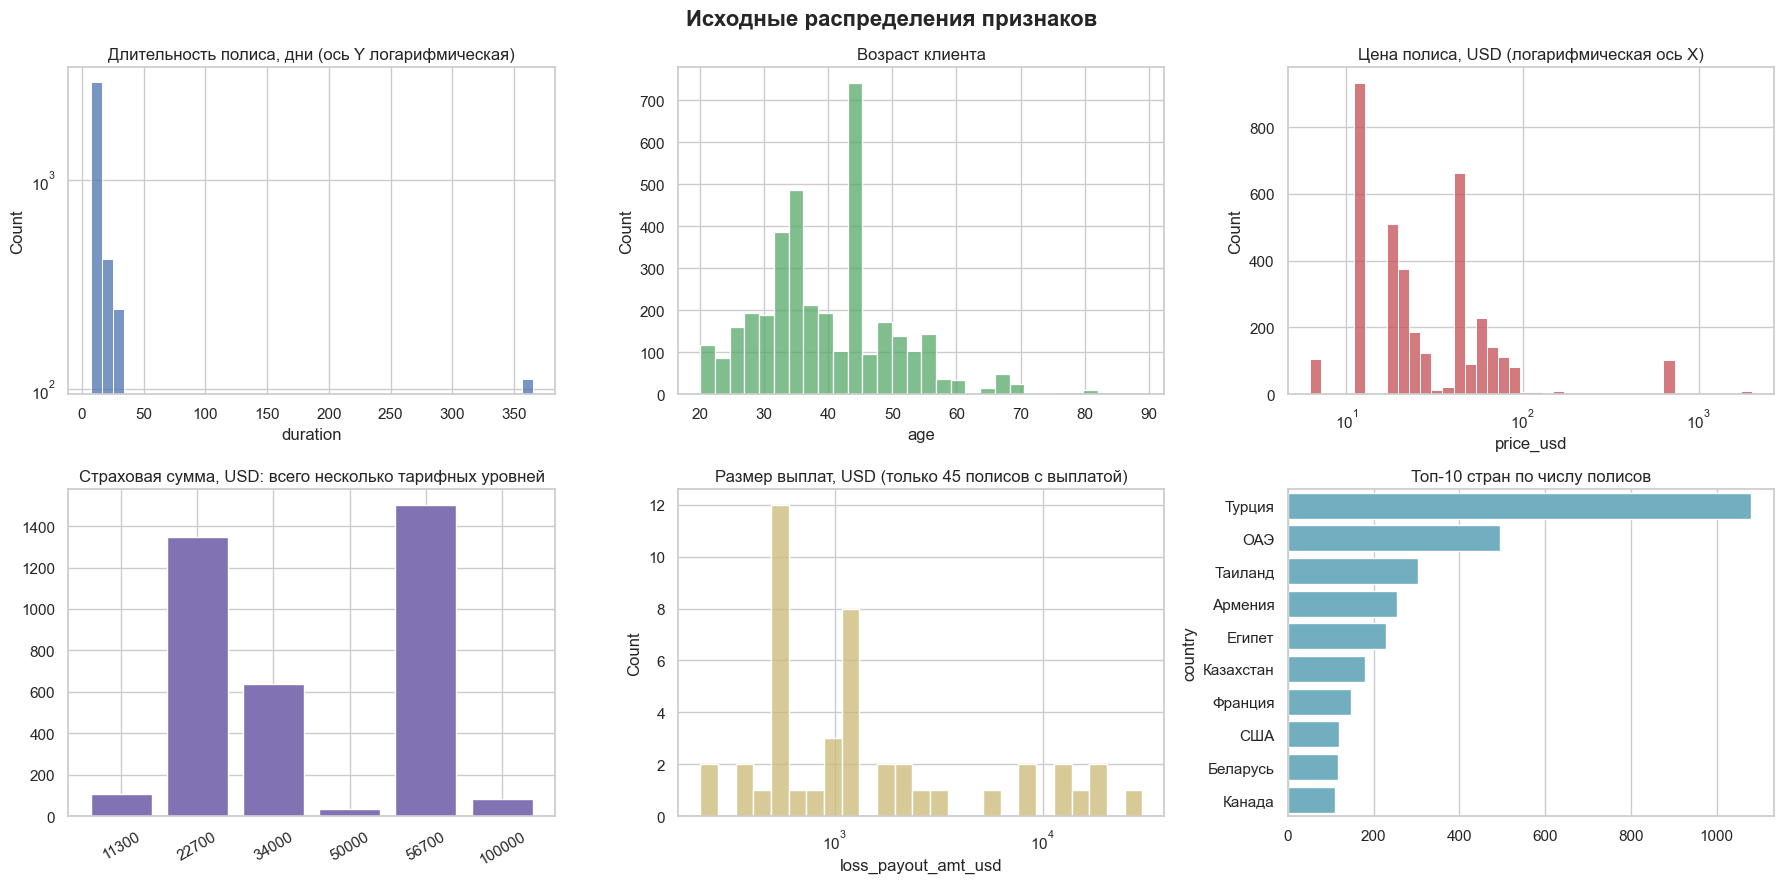

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Исходные распределения признаков', fontsize=16, fontweight='bold')

sns.histplot(df['duration'], bins=40, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Длительность полиса, дни (ось Y логарифмическая)')

sns.histplot(df['age'], bins=30, ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Возраст клиента')

sns.histplot(df['price_usd'], bins=40, ax=axes[0, 2], color='#C44E52', log_scale=True)
axes[0, 2].set_title('Цена полиса, USD (логарифмическая ось X)')

ins_counts = df['insurance_amount_usd'].round(-2).astype(int).value_counts().sort_index()
axes[1, 0].bar(ins_counts.index.astype(str), ins_counts.values, color='#8172B3')
axes[1, 0].set_title('Страховая сумма, USD: всего несколько тарифных уровней')
axes[1, 0].tick_params(axis='x', rotation=30)

sns.histplot(df.loc[claims_mask, 'loss_payout_amt_usd'], bins=25, ax=axes[1, 1], color='#CCB974', log_scale=True)
axes[1, 1].set_title(f'Размер выплат, USD (только {claims_mask.sum()} полисов с выплатой)')

top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1, 2], color='#64B5CD')
axes[1, 2].set_title('Топ-10 стран по числу полисов')

plt.tight_layout()
plt.show()

**Выводы по первичному анализу**

- Таблица содержит 3711 полисов, пропусков нет.
- `duration` и `price_usd` сильно скошены: почти все полисы рассчитаны на 7–30 дней, но есть 111 годовых (365 дней) с ценой в сотни долларов. Без преобразования эти наблюдения растянут шкалу и «перетянут» на себя кластеризацию.
- `insurance_amount_usd` принимает всего 6 значений, то есть это тарифные уровни, а не непрерывная величина.
- **Выплаты очень редки:** 45 полисов из 3711 (1,2%). Две крупнейшие выплаты ($30 000 и $20 000, обе по полисам в USD) составляют 30,7% всех выплат. Поэтому оценки убыточности по группам будут шумными, и ниже к ним добавлены доверительные интервалы.
- Общая убыточность портфеля: 81,2%.
- Валюта полностью совпадает со страной: все 120 полисов в USD оформлены на клиентов из США. Поэтому `currency_name` не даёт информации сверх `country`, а `product_name` дублирует валюту.
- `contract_num` замаскирован (79 значений на 3711 строк), а 664 строки полностью совпадают. По замаскированному номеру нельзя отличить дубликат от отдельного полиса по групповому договору, поэтому строки не удалялись. Это ограничение стоит иметь в виду: повторяющиеся строки увеличивают вес часто встречающихся профилей и завышают собранную премию. Влияние проверено в конце раздела 6: ни в одной из дублирующихся строк нет выплат, поэтому без них убыточность выше (81% → 96% по портфелю), но выводы не меняются.

## 2. Подготовка признаков

| Решение | Обоснование |
|---|---|
| Убрать `contract_num`, `product_name` | идентификатор и дубль валюты, кластеризации не помогают |
| Оставить только суммы в USD (`price_usd`, `insurance_amount_usd`), убрать те же величины в исходной валюте | единая шкала сумм, без дублирования |
| **Не включать `loss_payout_amt_usd` в признаки** | это целевая величина: убыточность анализируем после кластеризации |
| Логарифм (`log1p`) для `duration` и `price_usd` | сильная правая асимметрия из-за годовых полисов |
| `StandardScaler` для числовых признаков | K-Means и Ward работают с расстояниями, признаки должны быть в одном масштабе |
| Для набора B: One-Hot вместо LabelEncoder | страна и статус не упорядочены; числовые коды ввели бы ложный порядок и ложные расстояния |
| `currency_name` не берём в набор B | полностью дублирует `country = США` |
| `anomaly` берём в набор B как категориальный признак | значения -1 и 1 - это флаг, а не число |

Получаем два набора: **A** (4 числовых признака) и **B** (числовые + One-Hot категориальных).

,асимметрия до,асимметрия после
duration,5.46,3.59
age,0.87,0.87
price_usd,8.13,1.58
insurance_amount_usd,0.68,0.68


Набор A (числовые): (3711, 4)
Набор B (все, One-Hot): (3711, 30)  (из них 26 бинарных столбцов)


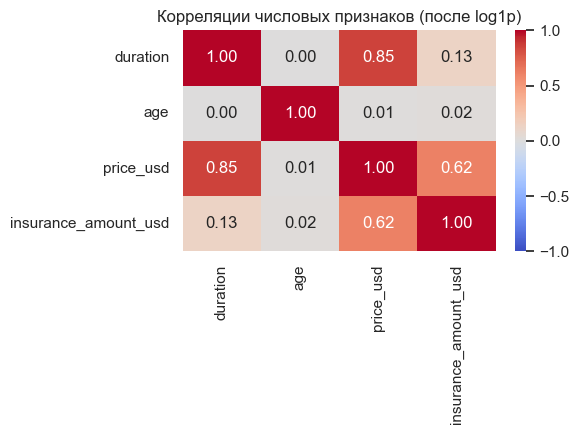

In [5]:
# --- что кластеризуем, а что нет ---------------------------------------------------
# убираем: contract_num (замаскированный идентификатор), product_name (дублирует currency_name),
#          price / insurance_amount / loss_payout_amt (те же величины в исходной валюте,
#          оставляем только версии в USD, чтобы все суммы были сопоставимы).
# loss_payout_amt_usd НЕ входит в признаки: это целевая величина (убыточность). Если её включить,
# кластеры будут разделять клиентов по уже произошедшим выплатам, и вывод «кластеры влияют на убыточность»
# станет тавтологией. Убыточность анализируем ПОСЛЕ кластеризации.
# currency_name не берём во вторую модель: он полностью совпадает с country == 'США' (см. таблицу выше)

NUM_COLS = ['duration', 'age', 'price_usd', 'insurance_amount_usd']
CAT_COLS = ['contract_status', 'country', 'sex', 'anomaly']

X_num = df[NUM_COLS].copy()
skew_before = X_num.skew()

# длительность и цена сильно скошены (несколько годовых полисов на фоне полисов 7-30 дней)
# логарифм сжимает хвост, иначе 111 годовых полисов «перетягивают» на себя всю шкалу
for col in ['duration', 'price_usd']:
    X_num[col] = np.log1p(X_num[col])
skew_after = X_num.skew()

display(pd.DataFrame({'асимметрия до': skew_before, 'асимметрия после': skew_after}).round(2))

scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=NUM_COLS, index=df.index)

# набор A - только числовые признаки
XA = X_num_scaled.copy()

# набор B - числовые + категориальные (One-Hot; drop_first не используем: для метрик расстояния
# отброшенная категория делает расстояния несимметричными)
X_cat_ohe = pd.get_dummies(df[CAT_COLS].astype(str), dtype=int)
XB = pd.concat([X_num_scaled, X_cat_ohe], axis=1)

print(f'Набор A (числовые): {XA.shape}')
print(f'Набор B (все, One-Hot): {XB.shape}  (из них {X_cat_ohe.shape[1]} бинарных столбцов)')

# корреляции числовых признаков (после логарифма)
plt.figure(figsize=(6, 4.5))
sns.heatmap(X_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляции числовых признаков (после log1p)')
plt.tight_layout()
plt.show()

**Вывод.** Логарифм заметно снижает асимметрию: у `price_usd` с 8,1 до 1,6, у `duration` с 5,5 до 3,6 (остаточная асимметрия связана с годовыми полисами, и это содержательная группа, а не ошибка). Длительность и цена сильно коррелируют (0,85), цена и страховая сумма тоже (0,62), то есть часть информации дублируется. Влияние этого дублирования проверим в разделе 4.

## 3. Выбор числа кластеров

Для K-Means и иерархической кластеризации (метод Ward) на обоих наборах признаков считаем три метрики при k от 2 до 8. Для K-Means добавлен метод локтя (inertia). Вертикальная пунктирная линия на графиках отмечает k = 3 (обоснование ниже).

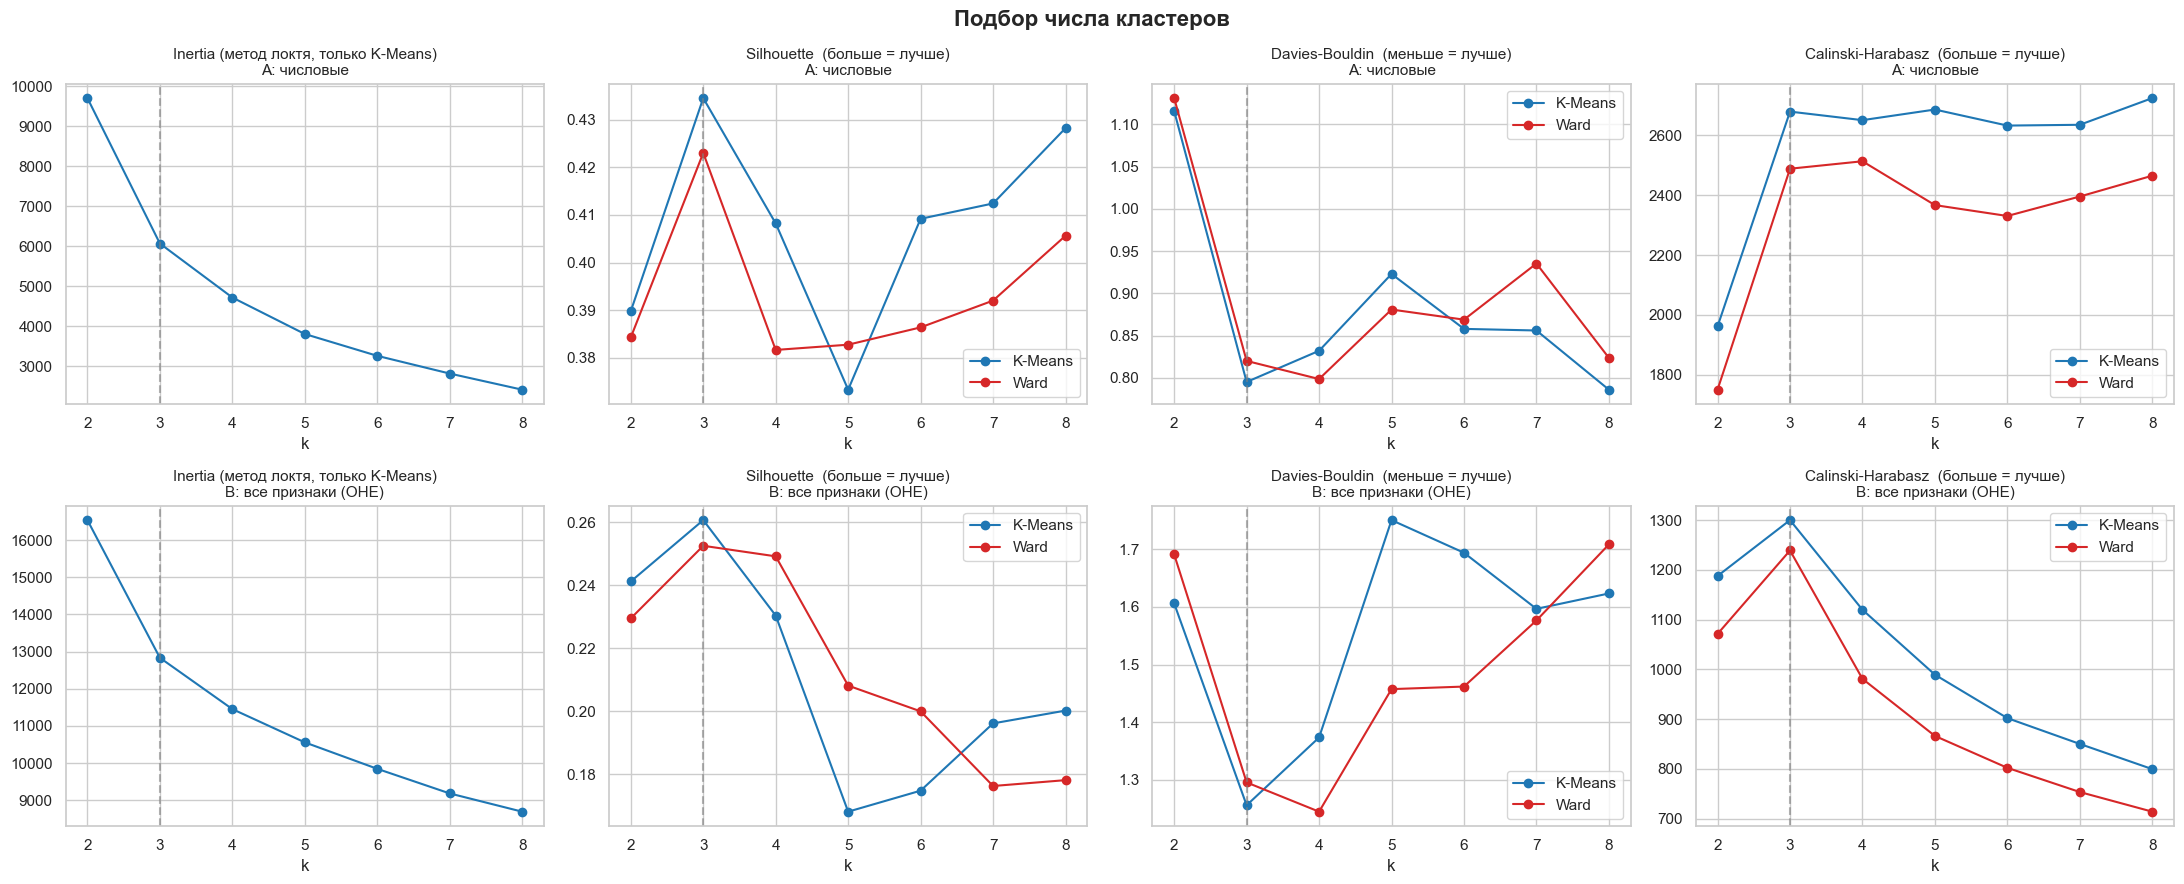

,признаки,метод,k по silhouette,k по Davies-Bouldin,k по Calinski-Harabasz
0,A: числовые,K-Means,3,8,8
1,A: числовые,Ward,3,4,4
2,B: все признаки (OHE),K-Means,3,3,3
3,B: все признаки (OHE),Ward,3,4,3


silhouette  davies_bouldin  calinski_harabasz
features              method  k                                               
A: числовые           K-Means 2       0.390           1.116           1961.682
                              3       0.435           0.795           2679.245
                              4       0.408           0.832           2650.675
                              5       0.373           0.923           2686.184
                      Ward    2       0.384           1.131           1750.429
                              3       0.423           0.820           2488.493
                              4       0.382           0.799           2513.381
                              5       0.383           0.881           2366.941
B: все признаки (OHE) K-Means 2       0.241           1.606           1187.970
                              3       0.261           1.256           1300.305
                              4       0.230           1.373           1120.044
                              5       0.168           1.751            989.500
                      Ward    2       0.229           1.691           1071.432
                              3       0.253           1.295           1239.248
                              4       0.249           1.245            981.145
                              5       0.208           1.457            866.375

In [6]:
K_RANGE = range(2, 9)

def evaluate(X, features_name):
    """K-Means и иерархическая (Ward) кластеризация для k = 2..8 с тремя метриками качества."""
    rows = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
        hc_labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)
        for method, labels, inertia in [('K-Means', km.labels_, km.inertia_),
                                        ('Ward', hc_labels, np.nan)]:
            rows.append({'features': features_name, 'method': method, 'k': k,
                         'silhouette': silhouette_score(X, labels),
                         'davies_bouldin': davies_bouldin_score(X, labels),
                         'calinski_harabasz': calinski_harabasz_score(X, labels),
                         'inertia': inertia})
    return pd.DataFrame(rows)

metrics = pd.concat([evaluate(XA, 'A: числовые'), evaluate(XB, 'B: все признаки (OHE)')],
                    ignore_index=True)

# --- графики: строки - наборы признаков, столбцы - метрики -----------------------
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Подбор числа кластеров', fontsize=16, fontweight='bold')
titles = [('inertia', 'Inertia (метод локтя, только K-Means)'),
          ('silhouette', 'Silhouette  (больше = лучше)'),
          ('davies_bouldin', 'Davies-Bouldin  (меньше = лучше)'),
          ('calinski_harabasz', 'Calinski-Harabasz  (больше = лучше)')]
for r, feat in enumerate(['A: числовые', 'B: все признаки (OHE)']):
    for c, (metric, title) in enumerate(titles):
        ax = axes[r, c]
        for method, color in [('K-Means', 'tab:blue'), ('Ward', 'tab:red')]:
            part = metrics[(metrics['features'] == feat) & (metrics['method'] == method)]
            if metric == 'inertia' and method == 'Ward':
                continue
            ax.plot(part['k'], part[metric], marker='o', color=color, label=method)
        ax.axvline(3, color='gray', linestyle='--', alpha=0.6)
        ax.set_title(f'{title}\n{feat}', fontsize=11)
        ax.set_xlabel('k')
        ax.set_xticks(list(K_RANGE))
        if metric != 'inertia':
            ax.legend()
plt.tight_layout()
plt.show()

# --- лучшее k по каждой метрике ---------------------------------------------------
best_rows = []
for (feat, method), g in metrics.groupby(['features', 'method']):
    best_rows.append({'признаки': feat, 'метод': method,
                      'k по silhouette': int(g.loc[g['silhouette'].idxmax(), 'k']),
                      'k по Davies-Bouldin': int(g.loc[g['davies_bouldin'].idxmin(), 'k']),
                      'k по Calinski-Harabasz': int(g.loc[g['calinski_harabasz'].idxmax(), 'k'])})
display(pd.DataFrame(best_rows))

display(metrics[metrics['k'].between(2, 5)].round(3).set_index(['features', 'method', 'k'])
        .drop(columns='inertia').sort_index())

**Выводы по метрикам**

- Во всех четырёх комбинациях (K-Means и Ward, наборы A и B) **silhouette максимален при k = 3**: K-Means на A 0,435, Ward на A 0,423, K-Means на B 0,261, Ward на B 0,253.
- Метод локтя для K-Means: при переходе 2 → 3 inertia падает с 9709 до 6071 (на 3638), при 3 → 4 только на 1351. Излом приходится на k = 3.
- Davies-Bouldin и Calinski-Harabasz на наборе A при k = 3 резко улучшаются по сравнению с k = 2, а при дальнейшем росте k не улучшаются заметно (DB колеблется в диапазоне 0,79–0,92, CH держится около 2600–2700). Формально лучшие значения K-Means достигает при k = 8 (DB 0,786 против 0,795, CH 2724 против 2679), но выигрыш ничтожен, а silhouette при этом ниже (0,428 против 0,435). Дробить клиентов на 8 групп ради такого улучшения нет смысла: сегменты перестанут быть интерпретируемыми.
- На наборе B при k = 3 лучшие значения у K-Means по всем трём метрикам; у Ward лучше всего k = 3 по silhouette и CH, а по Davies-Bouldin k = 4 лишь немного лучше (1,245 против 1,295).

Итог: по совокупности метрик выбираем **k = 3**.

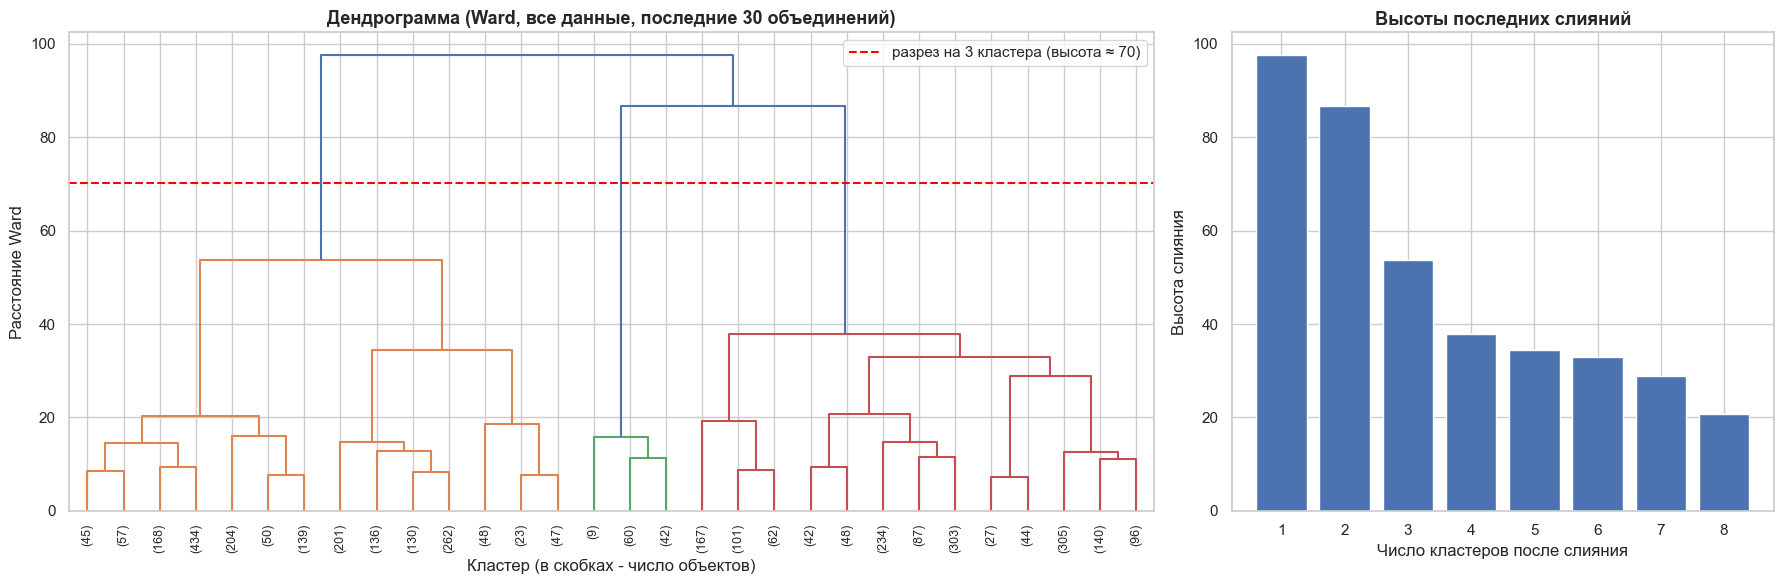

Высоты слияний (число кластеров после слияния -> высота):
  1 ->     97.6
  2 ->     86.6
  3 ->     53.8
  4 ->     37.9
  5 ->     34.5
  6 ->     32.9
  7 ->     28.9
  8 ->     20.8


In [7]:
# дендрограмма строится по ВСЕМ 3711 наблюдениям (метод Ward, признаки набора A),
# показаны только последние 30 объединений - иначе рисунок нечитаем.
Z = linkage(XA, method='ward')

# высота, на которой дерево «режется» на 3 кластера: между слиянием 4->3 и слиянием 3->2
cut_height = (Z[-3, 2] + Z[-2, 2]) / 2

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})

dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True, leaf_rotation=90,
           leaf_font_size=9, ax=axes[0])
axes[0].axhline(cut_height, color='red', linestyle='--', label=f'разрез на 3 кластера (высота ≈ {cut_height:.0f})')
axes[0].set_title('Дендрограмма (Ward, все данные, последние 30 объединений)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Кластер (в скобках - число объектов)')
axes[0].set_ylabel('Расстояние Ward')
axes[0].legend()

# высоты последних объединений: резкий скачок = «неестественное» слияние двух далёких групп
n_last = 8
heights = Z[-n_last:, 2][::-1]                    # от последнего слияния к более ранним
ks_after = np.arange(1, n_last + 1)               # число кластеров ПОСЛЕ слияния
axes[1].bar(ks_after, heights, color='#4C72B0')
axes[1].set_xlabel('Число кластеров после слияния')
axes[1].set_ylabel('Высота слияния')
axes[1].set_title('Высоты последних слияний', fontsize=13, fontweight='bold')
axes[1].set_xticks(ks_after)
plt.tight_layout()
plt.show()

print('Высоты слияний (число кластеров после слияния -> высота):')
for k_after, h in zip(ks_after, heights):
    print(f'  {k_after} -> {h:8.1f}')

**Вывод по дендрограмме.** Дерево (Ward, все 3711 объектов) имеет три крупные ветви: самая маленькая содержит 111 объектов (зелёная ветвь справа, это годовые полисы). Красная линия на высоте около 70 разрезает дерево ровно на три кластера. Слияния 3 → 2 (≈ 87) и 2 → 1 (≈ 98) происходят на большой высоте, а между 4 → 3 (≈ 54) и 3 → 2 (≈ 87) находится самый большой разрыв. Ниже идёт плотный ряд слияний (38, 35, 33, 29, 21) без явных разрывов, поэтому дробление на большее число кластеров структурой данных не подкрепляется. Дендрограмма подтверждает k = 3.

## 4. Сравнение методов и наборов признаков

Обучаем четыре модели с k = 3: K-Means и Ward на наборах A и B. Номера кластеров упорядочены по средней длительности полиса, поэтому они одинаковы для всех моделей. Значения метрик сравнимы только внутри одного набора признаков (пространства A и B разные), а согласованность разбиений измеряем индексом ARI.

,silhouette,Davies-Bouldin,Calinski-Harabasz,размеры кластеров
модель,,,,
K-Means | A,0.435,0.795,2679.245,"[1896, 1704, 111]"
Ward | A,0.423,0.820,2488.493,"[1944, 1656, 111]"
K-Means | B,0.261,1.256,1300.305,"[1896, 1704, 111]"
Ward | B,0.253,1.295,1239.248,"[1911, 1689, 111]"


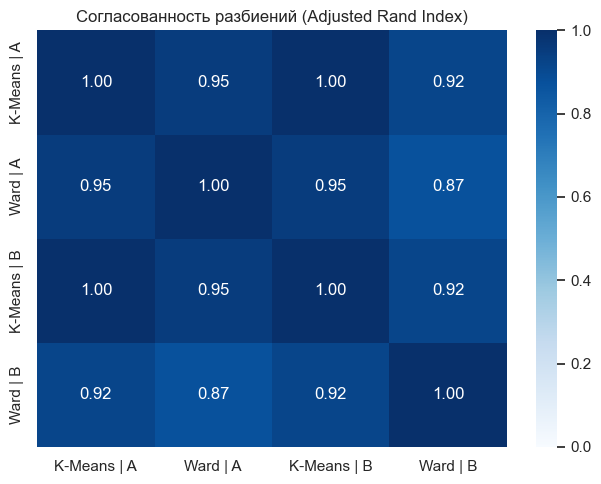

In [8]:
K_FINAL = 3

def relabel_by_duration(labels):
    """Нумерует кластеры по возрастанию средней длительности полиса,
    чтобы номера были одинаковыми при любом запуске и для любого метода."""
    order = pd.Series(df['duration'].values).groupby(labels).mean().sort_values().index
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[l] for l in labels])

models = {}
for feat_name, X in [('A', XA), ('B', XB)]:
    km_labels = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE).fit_predict(X)
    hc_labels = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward').fit_predict(X)
    models[f'K-Means | {feat_name}'] = (relabel_by_duration(km_labels), X)
    models[f'Ward | {feat_name}'] = (relabel_by_duration(hc_labels), X)

rows = []
for name, (labels, X) in models.items():
    rows.append({'модель': name,
                 'silhouette': silhouette_score(X, labels),
                 'Davies-Bouldin': davies_bouldin_score(X, labels),
                 'Calinski-Harabasz': calinski_harabasz_score(X, labels),
                 'размеры кластеров': np.bincount(labels).tolist()})
comparison = pd.DataFrame(rows).set_index('модель')
display(comparison.round(3))

# насколько модели согласуются между собой (ARI = 1 - разбиения совпадают)
names = list(models)
ari = pd.DataFrame([[adjusted_rand_score(models[a][0], models[b][0]) for b in names] for a in names],
                   index=names, columns=names)
plt.figure(figsize=(6.5, 5))
sns.heatmap(ari, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title('Согласованность разбиений (Adjusted Rand Index)')
plt.tight_layout()
plt.show()

**Выводы**

1. **K-Means или иерархическая кластеризация.** На наборе A K-Means лучше Ward по всем трём метрикам (silhouette 0,435 против 0,423; Davies-Bouldin 0,795 против 0,820; Calinski-Harabasz 2679 против 2488). Разбиения почти совпадают (ARI = 0,95), кластер годовых полисов из 111 клиентов у них идентичен, различаются лишь граничные полисы между двумя крупными группами. Для дальнейшего анализа выбираем **K-Means**: метрики лучше, центроиды легко интерпретировать, метод масштабируется на большие выборки. Иерархическая кластеризация оказалась полезна для выбора k (дендрограмма).
2. **Только числовые признаки или все признаки.** K-Means на наборе B даёт **в точности то же разбиение**, что на наборе A (ARI = 1,00): категориальные признаки не добавили новой структуры. При этом качество по метрикам на B ниже (silhouette 0,261, Davies-Bouldin 1,256), а разбиение Ward на B менее согласовано с остальными (ARI 0,87–0,92). Прямое сравнение значений silhouette между A и B некорректно (разные пространства), но вывод очевиден из совпадения разбиений.
3. **Почему методы лучше работают на числовых признаках.** K-Means и Ward используют евклидово расстояние. Среднее бинарного признака (доля страны в кластере) не имеет смысла центра, любые две разные страны одинаково «далеки» (расстояние √2, хотя Турция и ОАЭ похожи между собой больше, чем Турция и Канада), а 26 бинарных столбцов добавляют размерность и шум и «разбавляют» существенные числовые признаки. LabelEncoder был бы ещё хуже: он навязал бы странам порядок. Для смешанных данных корректнее K-Prototypes или расстояние Гауэра (см. раздел 7).

**Выбранная модель: K-Means, набор A (числовые признаки), k = 3.**

In [9]:
# проверка устойчивости выбранной модели (K-Means, набор A, k = 3)
base_labels = models['K-Means | A'][0]

# 1) другие random_state
seed_ari = [adjusted_rand_score(base_labels,
                                KMeans(K_FINAL, n_init=10, random_state=s).fit_predict(XA))
            for s in [1, 7, 123, 2024]]
print('ARI при других random_state:', np.round(seed_ari, 3))

# 2) без price_usd (цена на 0.85 коррелирует с длительностью и, по сути, дублирует её)
XA_no_price = XA.drop(columns='price_usd')
labels_no_price = KMeans(K_FINAL, n_init=10, random_state=RANDOM_STATE).fit_predict(XA_no_price)
print(f'ARI без признака price_usd: {adjusted_rand_score(base_labels, labels_no_price):.3f}, '
      f'размеры кластеров: {np.bincount(labels_no_price).tolist()}')

# 3) без логарифма (проверяем, насколько результат зависит от этого преобразования)
X_raw_scaled = StandardScaler().fit_transform(df[NUM_COLS])
raw_labels = KMeans(K_FINAL, n_init=10, random_state=RANDOM_STATE).fit_predict(X_raw_scaled)
print(f'ARI без log1p-преобразования: {adjusted_rand_score(base_labels, raw_labels):.3f}, '
      f'размеры кластеров без логарифма: {np.bincount(raw_labels).tolist()}')

ARI при других random_state: [1. 1. 1. 1.]
ARI без признака price_usd: 0.908, размеры кластеров: [1614, 1986, 111]
ARI без log1p-преобразования: 0.908, размеры кластеров без логарифма: [1614, 1986, 111]


**Вывод об устойчивости.** При других значениях `random_state` разбиение не меняется (ARI = 1). Без `price_usd` (он дублирует длительность) и без логарифмирования ARI равен 0,91: меняется только граница между двумя крупными группами, а годовые полисы во всех вариантах образуют один и тот же кластер из 111 клиентов. Оба варианта («без `price_usd`» и «без логарифма») дают одно и то же разбиение (ARI между ними 1,0, размеры кластеров 1614 / 1986 / 111): граница между двумя крупными группами сдвигается в них одинаково. Структура данных устойчива и не является артефактом преобразований.

## 5. Портреты кластеров

segment,Эконом,Расширенное покрытие,Годовые
полисов,1896.0,1704.0,111.0
"доля, %",51.1,45.9,3.0
"длительность, дн. (медиана)",10.0,14.0,365.0
возраст (средний),39.8,40.1,40.0
"цена, USD (медиана)",12.4,43.5,679.8
"страх. сумма, USD (среднее)",24686.0,57221.0,39342.0
"доля мужчин, %",62.7,61.3,56.8
"доля anomaly = -1, %",21.8,22.2,40.5
"доля завершённых, %",20.1,0.9,0.0
"доля полисов в USD, %",0.0,6.5,8.1


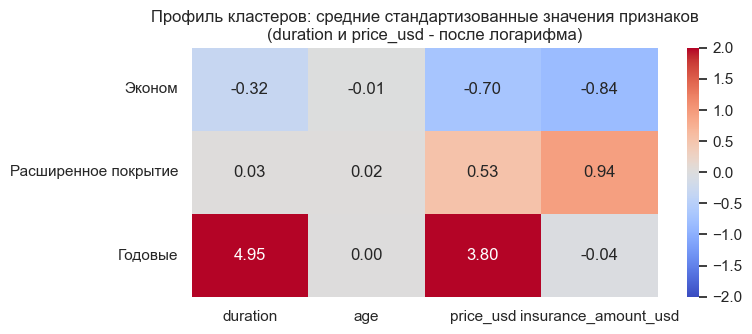

In [10]:
# финальная модель - K-Means на наборе A, k = 3
df['cluster'] = models['K-Means | A'][0]
SEGMENT_NAMES = {0: 'Эконом', 1: 'Расширенное покрытие', 2: 'Годовые'}
SEGMENT_ORDER = [SEGMENT_NAMES[i] for i in range(K_FINAL)]
df['segment'] = df['cluster'].map(SEGMENT_NAMES)
palette = dict(zip(SEGMENT_ORDER, ['#4C72B0', '#DD8452', '#55A868']))

g = df.groupby('segment')
profile = pd.DataFrame({
    'полисов': g.size(),
    'доля, %': (g.size() / len(df) * 100).round(1),
    'длительность, дн. (медиана)': g['duration'].median(),
    'возраст (средний)': g['age'].mean().round(1),
    'цена, USD (медиана)': g['price_usd'].median().round(1),
    'страх. сумма, USD (среднее)': g['insurance_amount_usd'].mean().round(0),
    'доля мужчин, %': (g['sex'].apply(lambda s: (s == 'M').mean()) * 100).round(1),
    'доля anomaly = -1, %': (g['anomaly'].apply(lambda s: (s == -1).mean()) * 100).round(1),
    'доля завершённых, %': (g['contract_status'].apply(lambda s: (s == 'Завершен').mean()) * 100).round(1),
    'доля полисов в USD, %': (g['currency_name'].apply(lambda s: (s == 'Доллар США').mean()) * 100).round(1),
}).loc[SEGMENT_ORDER]
display(profile.T)

# Z-профиль: на сколько стандартных отклонений кластер отличается от среднего по всем клиентам
z_profile = XA.groupby(df['segment']).mean().loc[SEGMENT_ORDER]
plt.figure(figsize=(8, 3.5))
sns.heatmap(z_profile, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-2, vmax=2)
plt.title('Профиль кластеров: средние стандартизованные значения признаков\n(duration и price_usd - после логарифма)')
plt.ylabel('')
plt.tight_layout()
plt.show()

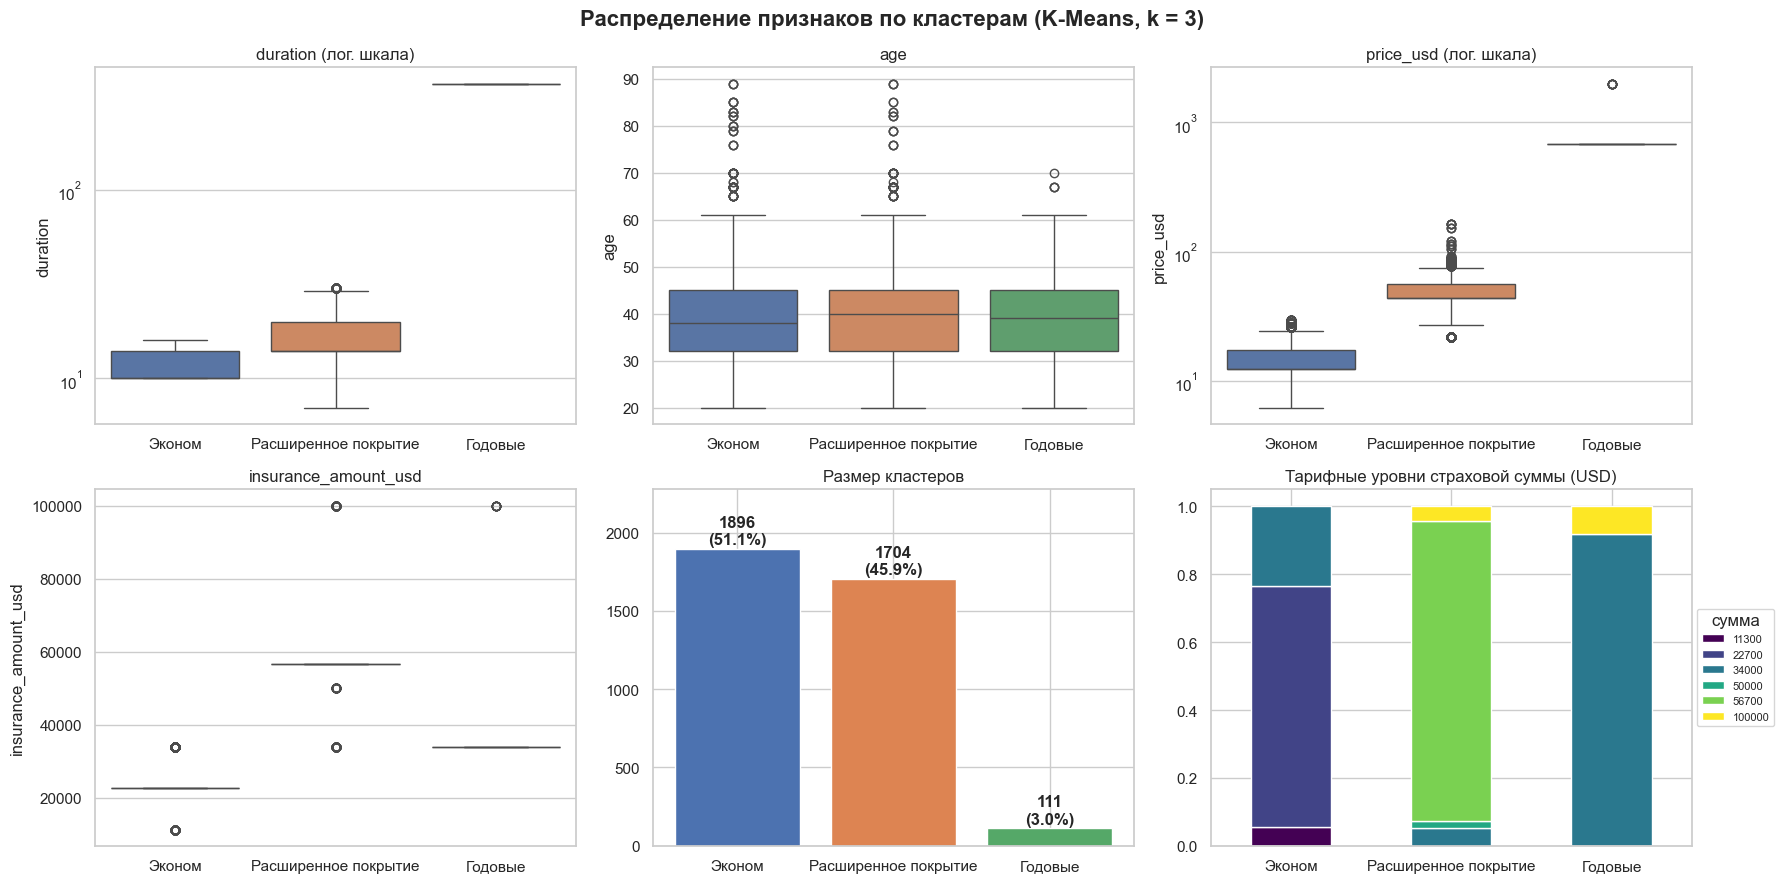

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Распределение признаков по кластерам (K-Means, k = 3)', fontsize=16, fontweight='bold')

for ax, col, log in zip(axes.ravel()[:4], NUM_COLS, [True, False, True, False]):
    sns.boxplot(data=df, x='segment', y=col, order=SEGMENT_ORDER, hue='segment',
                palette=palette, legend=False, ax=ax)
    if log:
        ax.set_yscale('log')
    ax.set_title(col + (' (лог. шкала)' if log else ''))
    ax.set_xlabel('')

sizes = df['segment'].value_counts().loc[SEGMENT_ORDER]
axes[1, 1].bar(sizes.index, sizes.values, color=[palette[s] for s in sizes.index])
for i, v in enumerate(sizes.values):
    axes[1, 1].text(i, v + 30, f'{v}\n({v / len(df):.1%})', ha='center', fontweight='bold')
axes[1, 1].set_ylim(0, sizes.max() * 1.2)
axes[1, 1].set_title('Размер кластеров')

ins_share = (pd.crosstab(df['segment'], df['insurance_amount_usd'].round(-2).astype(int), normalize='index')
             .loc[SEGMENT_ORDER])
ins_share.plot(kind='bar', stacked=True, ax=axes[1, 2], colormap='viridis', rot=0)
axes[1, 2].set_title('Тарифные уровни страховой суммы (USD)')
axes[1, 2].set_xlabel('')
axes[1, 2].legend(title='сумма', fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.show()

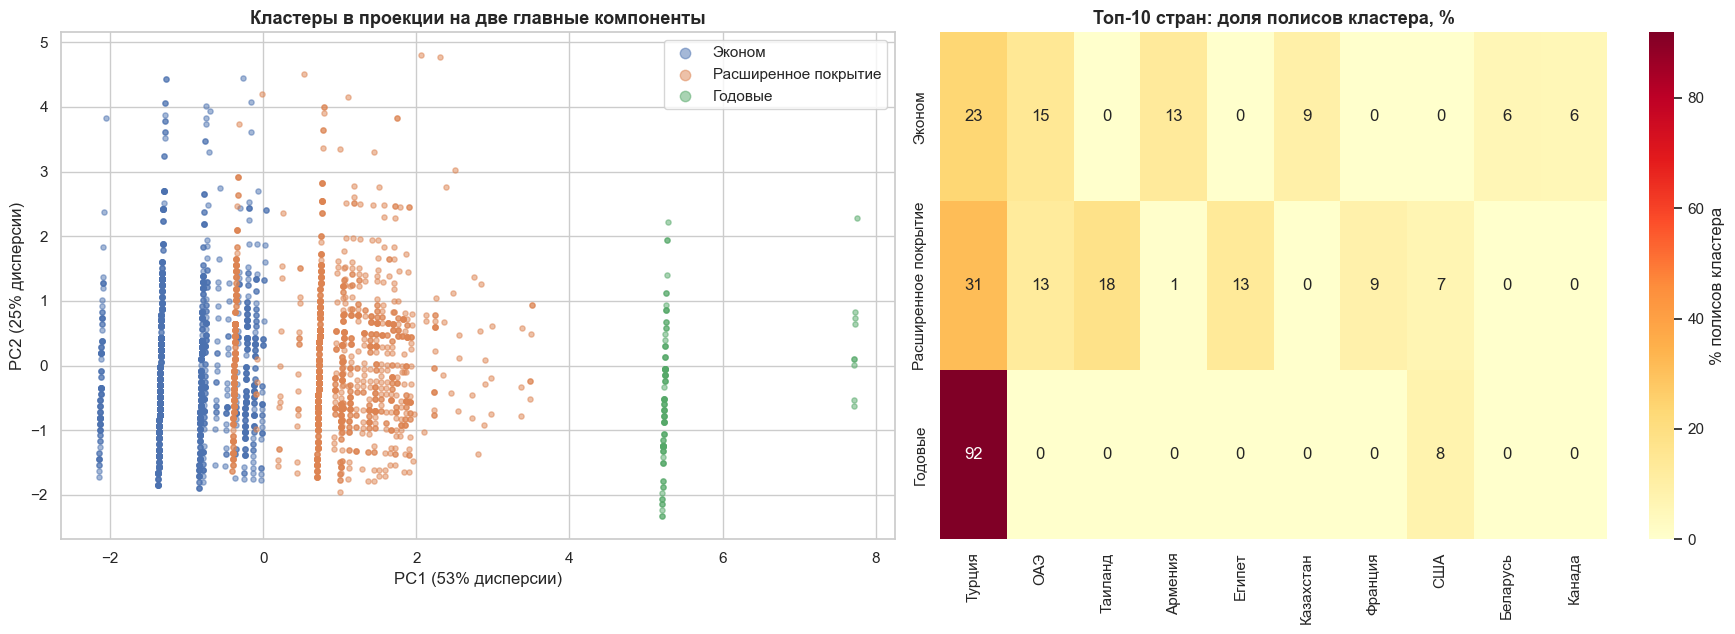

,PC1,PC2
duration,0.58,-0.09
age,0.02,0.99
price_usd,0.69,-0.02
insurance_amount_usd,0.45,0.10


In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(XA)

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

for seg in SEGMENT_ORDER:
    m = (df['segment'] == seg).values
    axes[0].scatter(coords[m, 0], coords[m, 1], s=14, alpha=0.5, label=seg, color=palette[seg])
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} дисперсии)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} дисперсии)')
axes[0].set_title('Кластеры в проекции на две главные компоненты', fontsize=13, fontweight='bold')
axes[0].legend(markerscale=2)

top10 = df['country'].value_counts().head(10).index
geo = pd.crosstab(df['segment'], df['country'], normalize='index').loc[SEGMENT_ORDER, top10] * 100
sns.heatmap(geo, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': '% полисов кластера'})
axes[1].set_title('Топ-10 стран: доля полисов кластера, %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

pc_load = pd.DataFrame(pca.components_.T, index=NUM_COLS, columns=['PC1', 'PC2']).round(2)
display(pc_load)

**Выводы по профилям**

- **Эконом** (1896 полисов, 51%): самые короткие и дешёвые полисы: медиана 10 дней, медианная цена около $12, средняя страховая сумма около $25 тыс. Только здесь есть заметная доля завершённых контрактов (20% против 0,9% и 0%), что объясняется короткой длительностью полисов. Полисов в USD нет.
- **Расширенное покрытие** (1704 полиса, 46%): поездки на 7–30 дней (медиана 14), цена выше (медиана около $43), самая высокая страховая сумма (в среднем около $57 тыс.; 88% полисов кластера относятся к верхнему рублёвому тарифу 5 млн руб.).
- **Годовые** (111 полисов, 3%): все полисы на 365 дней (z-оценка длительности +4,95), медианная цена около $680 при медиане по портфелю около $22, средняя страховая сумма около $39 тыс. Флаг `anomaly = -1` у 40,5% клиентов, вдвое чаще, чем в других кластерах (около 22%). Скорее всего, это следствие редкости годовых полисов в пространстве признаков, а не самостоятельный признак риска (об убыточности этого кластера см. раздел 6).
- **Возраст и пол кластеры не различают:** средний возраст около 40 лет и 57–63% мужчин в каждом кластере, доля клиентов 60+ составляет 4–4,5% везде. Значит, разбиение отражает тариф и продолжительность поездки, а не демографию.

**Выводы по графикам (PCA и география)**

- Первая главная компонента (53% дисперсии) объединяет длительность, цену и страховую сумму, годовые полисы уходят далеко вправо. Вторая компонента (25%) почти целиком состоит из возраста (нагрузка 0,99), и вдоль неё кластеры не разделяются: возраст в формировании сегментов участия не принимает.
- Кластеры тесно связаны с **направлением поездки**: Таиланд, Египет, Франция, Германия и Индонезия целиком попадают в «Расширенное покрытие», США на 93% (остальные в годовых); Казахстан, Беларусь, Грузия, Армения, Болгария, Иран, Сирия попадают почти целиком в «Эконом». Турция и ОАЭ распределены между сегментами (Турция: 49% «Расширенное», 41% «Эконом», остальное годовые). Годовые полисы на 92% турецкие. Для рекламы это означает, что тарифный уровень во многом определяется направлением.

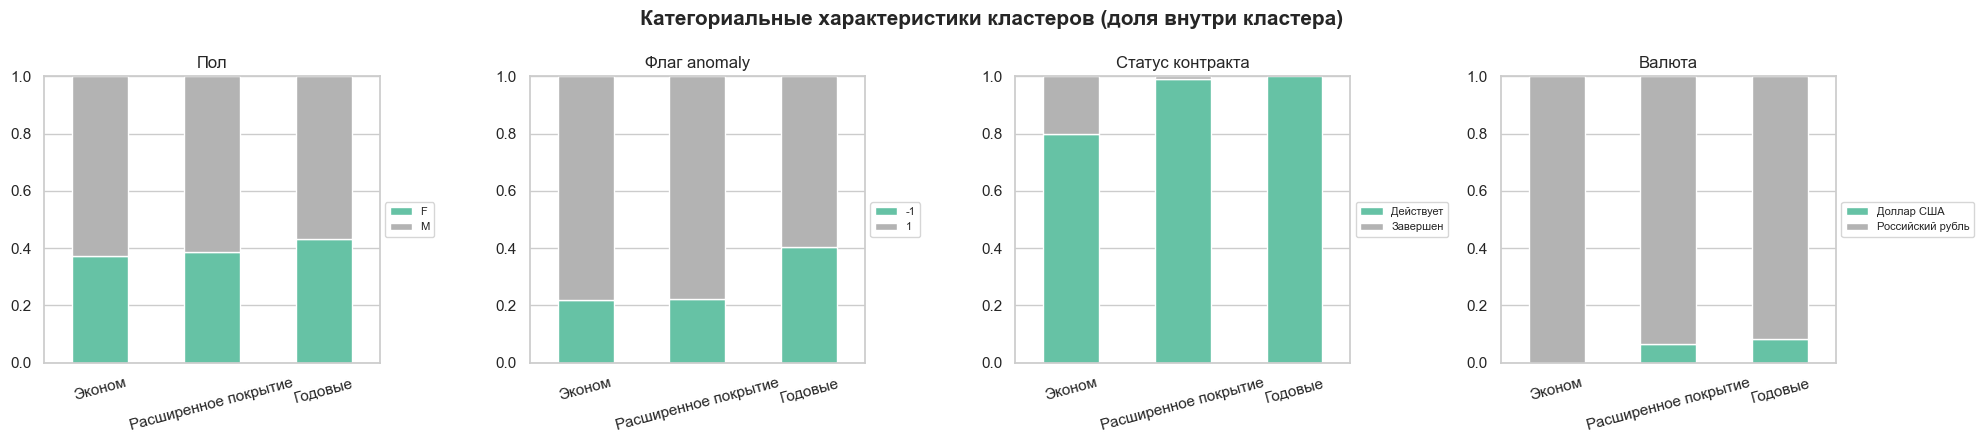

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle('Категориальные характеристики кластеров (доля внутри кластера)', fontsize=15, fontweight='bold')

cat_views = [('sex', 'Пол'), ('anomaly', 'Флаг anomaly'), ('contract_status', 'Статус контракта'),
             ('currency_name', 'Валюта')]
for ax, (col, title) in zip(axes, cat_views):
    share = pd.crosstab(df['segment'], df[col], normalize='index').loc[SEGMENT_ORDER]
    share.plot(kind='bar', stacked=True, ax=ax, rot=15, colormap='Set2')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

**Вывод.** Доля мужчин (57–63%) почти одинакова во всех кластерах. Завершённые контракты встречаются только в «Эконом», полисы в USD составляют 6,5% «Расширенного покрытия» и 8,1% «Годовых».

## 6. Убыточность кластеров

Для каждого сегмента считаем премию, выплаты, частоту и среднюю величину выплат и убыточность. Доверительный интервал (95%) получен бутстрепом по полисам: выплат всего 45, поэтому точечные оценки ненадёжны без интервалов.

,полисов,"премия, USD","выплаты, USD",случаев выплат,"частота выплат, %","средняя выплата, USD","убыточность, %","ДИ 95% (низ), %","ДИ 95% (верх), %","доля в премии, %","доля в выплатах, %"
сегмент,,,,,,,,,,,
Эконом,1896,30300.3,7931.0,10,0.5,793.1,26.2,11.2,46.6,15.1,4.9
Расширенное покрытие,1704,83067.3,149930.6,31,1.8,4836.5,180.5,79.5,298.2,41.4,92.0
Годовые,111,87339.6,5098.5,4,3.6,1274.6,5.8,0.3,15.3,43.5,3.1
Все клиенты,3711,200707.2,162960.1,45,1.2,3621.3,81.2,40.8,135.1,100.0,100.0


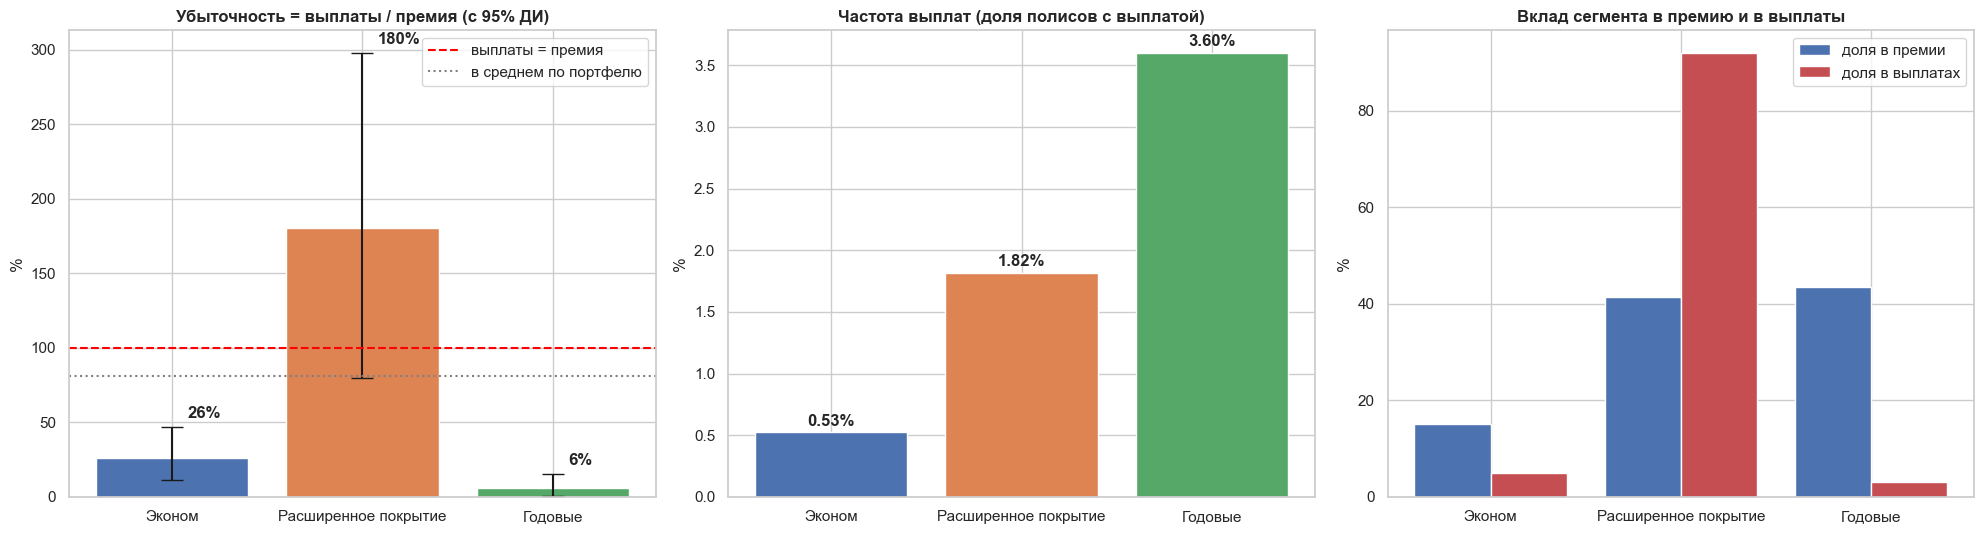

In [14]:
def bootstrap_loss_ratio(premium, loss, n_boot=2000, seed=RANDOM_STATE):
    """95%-интервал убыточности (сумма выплат / сумма премии) бутстрепом по полисам."""
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(premium), size=(n_boot, len(premium)))
    ratios = loss[idx].sum(axis=1) / premium[idx].sum(axis=1)
    return np.percentile(ratios, [2.5, 97.5])

rows = []
for seg in SEGMENT_ORDER + ['Все клиенты']:
    part = df if seg == 'Все клиенты' else df[df['segment'] == seg]
    prem = part['price_usd'].to_numpy()
    loss = part['loss_payout_amt_usd'].to_numpy()
    n_claims = int((loss > 0).sum())
    lo, hi = bootstrap_loss_ratio(prem, loss)
    rows.append({'сегмент': seg, 'полисов': len(part), 'премия, USD': prem.sum(), 'выплаты, USD': loss.sum(),
                 'случаев выплат': n_claims, 'частота выплат, %': n_claims / len(part) * 100,
                 'средняя выплата, USD': loss.sum() / n_claims if n_claims else np.nan,
                 'убыточность, %': loss.sum() / prem.sum() * 100,
                 'ДИ 95% (низ), %': lo * 100, 'ДИ 95% (верх), %': hi * 100,
                 'доля в премии, %': prem.sum() / total_premium * 100,
                 'доля в выплатах, %': loss.sum() / total_loss * 100})
loss_table = pd.DataFrame(rows).set_index('сегмент')
display(loss_table.round(1))

# --- визуализация -------------------------------------------------------------------
seg_tbl = loss_table.loc[SEGMENT_ORDER]
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
colors = [palette[s] for s in SEGMENT_ORDER]

err = np.vstack([seg_tbl['убыточность, %'] - seg_tbl['ДИ 95% (низ), %'],
                 seg_tbl['ДИ 95% (верх), %'] - seg_tbl['убыточность, %']])
axes[0].bar(SEGMENT_ORDER, seg_tbl['убыточность, %'], yerr=err, capsize=8, color=colors)
axes[0].axhline(100, color='red', linestyle='--', label='выплаты = премия')
axes[0].axhline(loss_table.loc['Все клиенты', 'убыточность, %'], color='gray', linestyle=':', label='в среднем по портфелю')
for i, (v, hi_) in enumerate(zip(seg_tbl['убыточность, %'], seg_tbl['ДИ 95% (верх), %'])):
    axes[0].text(i + 0.08, hi_ + 6, f'{v:.0f}%', ha='left', fontweight='bold')
axes[0].set_title('Убыточность = выплаты / премия (с 95% ДИ)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('%')
axes[0].legend()

axes[1].bar(SEGMENT_ORDER, seg_tbl['частота выплат, %'], color=colors)
for i, v in enumerate(seg_tbl['частота выплат, %']):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')
axes[1].set_title('Частота выплат (доля полисов с выплатой)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('%')

x = np.arange(K_FINAL)
axes[2].bar(x - 0.2, seg_tbl['доля в премии, %'], width=0.4, label='доля в премии', color='#4C72B0')
axes[2].bar(x + 0.2, seg_tbl['доля в выплатах, %'], width=0.4, label='доля в выплатах', color='#C44E52')
axes[2].set_xticks(x)
axes[2].set_xticklabels(SEGMENT_ORDER)
axes[2].set_title('Вклад сегмента в премию и в выплаты', fontsize=12, fontweight='bold')
axes[2].set_ylabel('%')
axes[2].legend()
plt.tight_layout()
plt.show()

**Выводы по убыточности сегментов**

- **Расширенное покрытие** даёт 41% премии, но **92% всех выплат**. Убыточность 180% (95% ДИ примерно 80–298%), частота выплат 1,8%, средняя выплата около $4,8 тыс. при средней премии около $49. Это единственный сегмент, в котором выплаты превышают премию.
- **Эконом**: убыточность 26% (ДИ 11–47%), выплаты редкие (0,5% полисов) и небольшие (в среднем около $0,8 тыс.). Сегмент прибыльный и самый массовый (51% полисов).
- **Годовые**: 3% полисов приносят 43,5% всей премии при 3% выплат; убыточность 5,8% (ДИ 0,3–15%). Частота выплат в этом сегменте самая высокая (3,6%), но всего 4 случая, и они небольшие относительно высокой премии.
- Портфель в целом: 81% (ДИ 41–135%). Широкий интервал напоминает, что оценки построены на 45 выплатах.

In [15]:
ext = df[df['segment'] == 'Расширенное покрытие']
top2_idx = ext['loss_payout_amt_usd'].nlargest(2).index
ext_wo = ext.drop(top2_idx)
print(f'Расширенное покрытие: убыточность {ext["loss_payout_amt_usd"].sum() / ext["price_usd"].sum():.0%}; '
      f'без двух крупнейших выплат (${ext.loc[top2_idx, "loss_payout_amt_usd"].sum():,.0f}) - '
      f'{ext_wo["loss_payout_amt_usd"].sum() / ext_wo["price_usd"].sum():.0%}')

# различается ли частота выплат между кластерами статистически?
ct = pd.crosstab(df['segment'], claims_mask)
chi2, p_value, _, _ = chi2_contingency(ct)
print(f'Хи-квадрат для частоты выплат по кластерам: p = {p_value:.4f}')

# аномальные записи: связаны ли они с убыточностью?
def loss_stats(t):
    """Сводка по группе полисов: частота выплат, убыточность и вклад в общие выплаты."""
    return pd.Series({'полисов': len(t),
                      'случаев выплат': int((t['loss_payout_amt_usd'] > 0).sum()),
                      'частота выплат, %': (t['loss_payout_amt_usd'] > 0).mean() * 100,
                      'убыточность, %': t['loss_payout_amt_usd'].sum() / t['price_usd'].sum() * 100,
                      'доля в выплатах, %': t['loss_payout_amt_usd'].sum() / total_loss * 100})

anom = df.groupby('anomaly')[['loss_payout_amt_usd', 'price_usd']].apply(loss_stats)
display(anom.round(1))

# различается ли убыточность у мужчин и женщин?
sex_tbl = df.groupby('sex')[['loss_payout_amt_usd', 'price_usd']].apply(loss_stats)
display(sex_tbl.round(1))

Расширенное покрытие: убыточность 180%; без двух крупнейших выплат ($50,000) - 120%
Хи-квадрат для частоты выплат по кластерам: p = 0.0001


,полисов,случаев выплат,"частота выплат, %","убыточность, %","доля в выплатах, %"
anomaly,,,,,
-1,837.0,27.0,3.2,138.8,50.4
1,2874.0,18.0,0.6,57.1,49.6


,полисов,случаев выплат,"частота выплат, %","убыточность, %","доля в выплатах, %"
sex,,,,,
F,1416.0,18.0,1.3,74.2,37.5
M,2295.0,27.0,1.2,86.0,62.5


,полисов,случаев выплат,"частота выплат, %","убыточность, %","доля в выплатах, %"
age_band,,,,,
20-29,555.0,7.0,1.3,85.0,14.0
30-39,1359.0,1.0,0.1,41.4,18.4
40-49,1218.0,2.0,0.2,30.9,13.0
50-59,420.0,8.0,1.9,98.4,14.2
60+,159.0,27.0,17.0,680.7,40.5


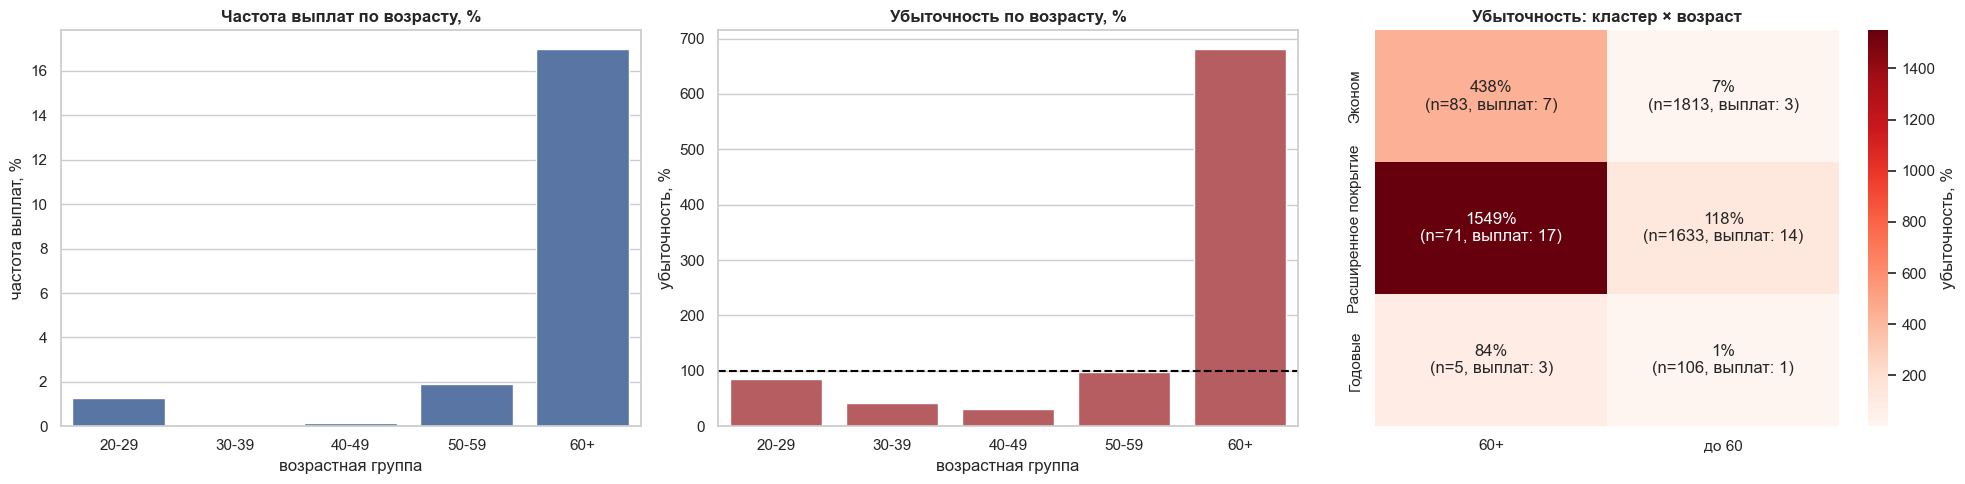

Расширенное покрытие без клиентов 60+ и без полисов в USD: 1529 полисов, убыточность 61%
Клиенты 60+ без их единственной крупнейшей выплаты ($16,995): убыточность 505%
Полисы в USD (все клиенты из США): 120 шт., убыточность 194%, выплат: 2


In [16]:
# возраст почти одинаков во всех кластерах (~40 лет), поэтому кластеризация его «не видит»
# но именно возраст может сильнее всего влиять на убыточность, проверяем отдельно
df['age_band'] = pd.cut(df['age'], bins=[19, 29, 39, 49, 59, 100],
                        labels=['20-29', '30-39', '40-49', '50-59', '60+'])

age_tbl = df.groupby('age_band', observed=True)[['loss_payout_amt_usd', 'price_usd']].apply(loss_stats)
display(age_tbl.round(1))

df['age_group'] = np.where(df['age'] >= 60, '60+', 'до 60')
seg_age = (df.groupby(['segment', 'age_group'])[['loss_payout_amt_usd', 'price_usd']].apply(loss_stats)
           .reset_index())
seg_age_lr = seg_age.pivot(index='segment', columns='age_group', values='убыточность, %').loc[SEGMENT_ORDER]
seg_age_n = seg_age.pivot(index='segment', columns='age_group', values='полисов').loc[SEGMENT_ORDER]
seg_age_claims = seg_age.pivot(index='segment', columns='age_group', values='случаев выплат').loc[SEGMENT_ORDER]
annot = seg_age_lr.round(0).astype(int).astype(str) + '%\n(n=' + seg_age_n.astype(int).astype(str) \
        + ', выплат: ' + seg_age_claims.astype(int).astype(str) + ')'

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(x=age_tbl.index.astype(str), y=age_tbl['частота выплат, %'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Частота выплат по возрасту, %', fontsize=12, fontweight='bold')
axes[0].set_xlabel('возрастная группа')
sns.barplot(x=age_tbl.index.astype(str), y=age_tbl['убыточность, %'], ax=axes[1], color='#C44E52')
axes[1].axhline(100, color='black', linestyle='--')
axes[1].set_title('Убыточность по возрасту, %', fontsize=12, fontweight='bold')
axes[1].set_xlabel('возрастная группа')
sns.heatmap(seg_age_lr, annot=annot, fmt='', cmap='Reds', ax=axes[2], cbar_kws={'label': 'убыточность, %'})
axes[2].set_title('Убыточность: кластер × возраст', fontsize=12, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('')
plt.tight_layout()
plt.show()

# что остаётся от убыточности расширенного покрытия, если убрать клиентов 60+ и полисы в USD (страна США)?
core = df[(df['segment'] == 'Расширенное покрытие') & (df['age'] < 60) & (df['currency_name'] != 'Доллар США')]
print(f'Расширенное покрытие без клиентов 60+ и без полисов в USD: {len(core)} полисов, '
      f'убыточность {core["loss_payout_amt_usd"].sum() / core["price_usd"].sum():.0%}')
age60 = df[df['age'] >= 60]
loss60 = age60['loss_payout_amt_usd']
print(f'Клиенты 60+ без их единственной крупнейшей выплаты (${loss60.max():,.0f}): '
      f'убыточность {(loss60.sum() - loss60.max()) / age60["price_usd"].sum():.0%}')
usd = df[df['currency_name'] == 'Доллар США']
print(f'Полисы в USD (все клиенты из США): {len(usd)} шт., '
      f'убыточность {usd["loss_payout_amt_usd"].sum() / usd["price_usd"].sum():.0%}, '
      f'выплат: {(usd["loss_payout_amt_usd"] > 0).sum()}')

**Проверка устойчивости выводов**

- Убыточность «Расширенного покрытия» без двух крупнейших выплат ($30 000 и $20 000) снижается со 180% до 120%: вывод сохраняется, но не так драматичен.
- Различие в частоте выплат между сегментами статистически значимо (хи-квадрат, p ≈ 0,0001).
- Флаг `anomaly = -1` связан с риском: частота выплат 3,2% против 0,6%, убыточность 139% против 57%. Однако флаг во многом отражает возраст: он стоит у 63,5% клиентов 60+ и у 20,7% остальных. Среди клиентов младше 60 лет разница в частоте выплат сохраняется (1,4% против 0,3%: 10 выплат на 736 помеченных полисов и 8 на 2816 остальных), но опирается на единицы случаев. Как флаг рассчитывался в предыдущем модуле, из задания неизвестно: если при его построении учитывались выплаты, связь с убыточностью была бы круговой. Поэтому как самостоятельный критерий отбора его использовать рано.
- Пол клиента на убыточность не влияет: частота выплат 1,3% у женщин и 1,2% у мужчин; различие убыточности (74% и 86%) лежит в пределах шума при 45 выплатах.

**Главный вывод раздела: возраст, который кластеризация «не увидела», сильнее всего связан с убыточностью**

- Клиенты **60+** составляют 4,3% полисов (159), но дают 27 из 45 выплат и 40,5% всех выплат. Частота выплат у них 17% (у клиентов младше 60 около 0,5%), убыточность 681%. Даже без их крупнейшей выплаты убыточность остаётся около 505%.
- Эта закономерность повторяется **внутри каждого кластера**: в «Эконом» убыточность клиентов младше 60 лет всего 7%, а у 60+ 438%; в «Расширенном покрытии» 118% и 1549%. В «Годовых» клиентов 60+ всего 5, вывод по ним статистически несостоятелен.
- Если из «Расширенного покрытия» убрать клиентов 60+ и полисы в USD (США), убыточность падает до **61%** (1529 полисов), то есть основная часть сегмента прибыльна. Проблема сосредоточена в двух подгруппах: клиенты 60+ и полисы США в USD (120 полисов, 2 крупные выплаты, убыточность 194%).
- Также повышена убыточность у клиентов 20–29 лет (85%, 7 выплат) и 50–59 лет (98%, 8 выплат), но эти оценки опираются на единицы случаев.
- Оговорка: группа 60+ невелика (159 полисов, 27 выплат). Вывод сильный, но его нужно подтвердить на большем объёме данных.

### Чувствительность к дубликатам

В разделе 1 отмечено 664 полных дубликата. Проверим, как их удаление влияет на убыточность и на сами кластеры.

In [17]:
# чувствительность к дубликатам: пересчитываем убыточность после удаления полностью совпадающих строк
# сегменты берём прежние (модель обучена на всех строках), а отдельно проверяем,
# не меняется ли разбиение, если обучить K-Means уже без дубликатов
in_dup_groups = df.duplicated(keep=False)
print(f'Строк в группах полных дубликатов: {int(in_dup_groups.sum())}, из них с выплатой: {int((in_dup_groups & claims_mask).sum())}')

df_dedup = df.drop_duplicates()
print(f'После drop_duplicates: {len(df_dedup)} полисов, выплат: {int((df_dedup["loss_payout_amt_usd"] > 0).sum())} '
      f'(было {len(df)} полисов и {int(claims_mask.sum())} выплат)')

def lr_by_segment(t):
    s = t.groupby('segment')[['loss_payout_amt_usd', 'price_usd']].sum().loc[SEGMENT_ORDER]
    lr = s['loss_payout_amt_usd'] / s['price_usd'] * 100
    lr['Все клиенты'] = t['loss_payout_amt_usd'].sum() / t['price_usd'].sum() * 100
    old = t['age'] >= 60
    lr['Клиенты 60+'] = t.loc[old, 'loss_payout_amt_usd'].sum() / t.loc[old, 'price_usd'].sum() * 100
    return lr

def n_by_segment(t):
    n = t['segment'].value_counts().loc[SEGMENT_ORDER]
    n['Все клиенты'] = len(t)
    n['Клиенты 60+'] = int((t['age'] >= 60).sum())
    return n

dedup_cmp = pd.DataFrame({'убыточность с дубликатами, %': lr_by_segment(df),
                          'убыточность без дубликатов, %': lr_by_segment(df_dedup),
                          'полисов с дубликатами': n_by_segment(df),
                          'полисов без дубликатов': n_by_segment(df_dedup)})
display(dedup_cmp.round(1))

# те же ли кластеры получаются, если обучить K-Means без дубликатов?
km_dd = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE).fit_predict(XA.loc[df_dedup.index])
order = pd.Series(df_dedup['duration'].values).groupby(km_dd).mean().sort_values().index
remap = {old: new for new, old in enumerate(order)}
km_dd = np.array([remap[l] for l in km_dd])
print(f'ARI между кластерами на полных данных и на данных без дубликатов: '
      f'{adjusted_rand_score(df_dedup["cluster"], km_dd):.3f}, размеры кластеров без дубликатов: {np.bincount(km_dd).tolist()}')

Строк в группах полных дубликатов: 1074, из них с выплатой: 0
После drop_duplicates: 3047 полисов, выплат: 45 (было 3711 полисов и 45 выплат)


,"убыточность с дубликатами, %","убыточность без дубликатов, %",полисов с дубликатами,полисов без дубликатов
segment,,,,
Эконом,26.2,31.6,1896,1566
Расширенное покрытие,180.5,212.7,1704,1390
Годовые,5.8,6.9,111,91
Все клиенты,81.2,96.2,3711,3047
Клиенты 60+,680.7,690.8,159,153


ARI между кластерами на полных данных и на данных без дубликатов: 1.000, размеры кластеров без дубликатов: [1566, 1390, 91]


**Вывод.** В 1074 строках, входящих в группы полных дубликатов (из них 664 лишние копии), нет ни одной выплаты. Удаление дубликатов убирает 664 полиса и ни одной выплаты (все 45 остаются), поэтому собранная премия уменьшается, а убыточность растёт: портфель 81% → 96%, «Расширенное покрытие» 180% → 213%, «Эконом» 26% → 32%, «Годовые» 6% → 7%, клиенты 60+ 681% → 691%.

Качественные выводы не меняются: ранжирование сегментов и роль возраста 60+ те же, а K-Means, обученный без дубликатов, даёт то же разбиение (ARI = 1,0). Меняется абсолютный уровень убыточности. Если повторяющиеся строки — технические копии, реальная убыточность ближе к значениям «без дубликатов»; если это отдельные полисы по групповым договорам, верны исходные значения. По замаскированному `contract_num` это не определить, поэтому в отчёте лучше указывать диапазон.

## 7. Необязательный блок: K-Prototypes

K-Prototypes (библиотека `kmodes`) работает с числовыми и категориальными признаками одновременно: для числовых считает евклидово расстояние, для категориальных долю несовпадений, а вместо среднего для категорий берёт моду. One-Hot кодирование при этом не нужно. Ячейка использует те же стандартизованные числовые признаки, что и набор A, плюс `contract_status`, `country`, `sex`, `anomaly`. Silhouette считается в пространстве B, чтобы значение можно было сравнить с K-Means и Ward на B.

*Ячейка использует библиотеку `kmodes` (установка - закомментированная строка в первой ячейке). Основные выводы разделов 3–6 от этого блока не зависят.*

k = 2: cost = 12,349.0
k = 3: cost = 10,820.1
k = 4: cost = 7,358.9
k = 5: cost = 6,624.6
k = 6: cost = 6,044.0


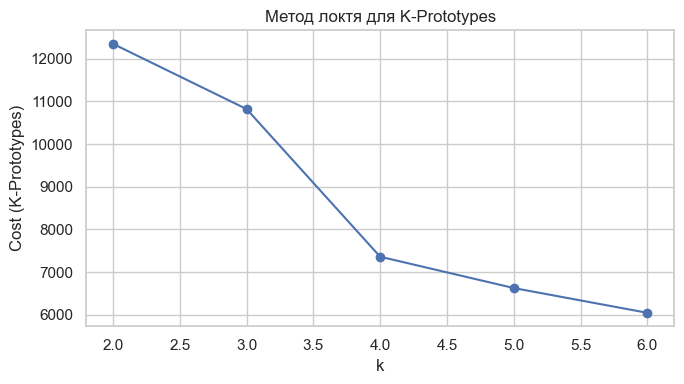

Размеры кластеров K-Prototypes: [1607, 754, 1350]
Silhouette (пространство B): 0.184
ARI K-Prototypes vs финальный K-Means: 0.472


K-Prototypes,0,1,2
K-Means,,,
Годовые,0,0,111
Расширенное покрытие,164,301,1239
Эконом,1443,453,0


In [18]:
# K-Prototypes (kmodes) - смешанные данные без One-Hot кодирования
try:
    from kmodes.kprototypes import KPrototypes
    KMODES_OK = True
except ImportError:
    KMODES_OK = False
    print('Библиотека kmodes не установлена: раскомментируйте `%pip install kmodes` в первой ячейке.')

if KMODES_OK:
    # числовые признаки (те же, что в наборе A, уже стандартизованные) + категориальные как строки
    df_kp = pd.concat([XA, df[CAT_COLS].astype(str)], axis=1)
    cat_idx = [df_kp.columns.get_loc(c) for c in CAT_COLS]      # индексы категориальных столбцов
    X_kp = df_kp.to_numpy()

    costs = []
    for k in range(2, 7):
        kp = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=RANDOM_STATE)
        kp.fit(X_kp, categorical=cat_idx)
        costs.append(kp.cost_)
        print(f'k = {k}: cost = {kp.cost_:,.1f}')

    plt.figure(figsize=(7, 4))
    plt.plot(range(2, 7), costs, marker='o')
    plt.xlabel('k')
    plt.ylabel('Cost (K-Prototypes)')
    plt.title('Метод локтя для K-Prototypes')
    plt.tight_layout()
    plt.show()

    kp3 = KPrototypes(n_clusters=K_FINAL, init='Cao', n_init=3, random_state=RANDOM_STATE)
    kp_labels = relabel_by_duration(kp3.fit_predict(X_kp, categorical=cat_idx))

    # Silhouette считаем в том же пространстве B, что и для K-Means | B / Ward | B, чтобы значения были сопоставимы
    print('Размеры кластеров K-Prototypes:', np.bincount(kp_labels).tolist())
    print(f'Silhouette (пространство B): {silhouette_score(XB, kp_labels):.3f}')
    print(f'ARI K-Prototypes vs финальный K-Means: {adjusted_rand_score(df["cluster"], kp_labels):.3f}')
    display(pd.crosstab(df['segment'], kp_labels, rownames=['K-Means'], colnames=['K-Prototypes']))

**Вывод по K-Prototypes.** При том же k = 3 метод даёт заметно иное разбиение, чем K-Means на числовых признаках: ARI = 0,47, размеры кластеров 1607 / 754 / 1350 против 1896 / 1704 / 111. Главное отличие видно по таблице сопряжённости: 111 годовых полисов не образуют отдельный кластер, а попадают в один кластер с 1239 из 1704 полисов «Расширенного покрытия», а «Эконом» и остальная часть «Расширенного покрытия» перемешаны между двумя другими кластерами (в кластер 1 вместе попадают 453 полиса «Эконом» и 301 «Расширенного покрытия»). Вероятно, так действует страна: это самый многозначный категориальный признак (20 значений), и он сильно влияет на границы кластеров.

Silhouette в пространстве B равен 0,184 и ниже, чем у K-Means (0,261) и Ward (0,253) на тех же признаках. Отчасти это ожидаемо: silhouette использует евклидово расстояние, а K-Prototypes оптимизирует другой критерий. Кривая cost падает резче при переходе от k = 3 к k = 4 (10 820 → 7 359), чем при переходе от 2 к 3, то есть в смешанном пространстве локоть указывает скорее на k = 4; значения cost при этом несопоставимы с inertia K-Means.

**Итог:** категориальные признаки размывают границу между тарифными сегментами и скрывают небольшой, но важный для бизнеса сегмент годовых полисов (3% полисов и 43,5% премии). Поэтому финальной моделью остаётся K-Means на числовых признаках, а результат K-Prototypes согласуется с выводом раздела 4: добавление категориальных признаков разбиение не улучшает.

## 8. Итоговые выводы и рекомендации для руководства

**Что сделано.** Сравнены иерархическая кластеризация (Ward) и K-Means на двух наборах признаков (числовые и все с One-Hot), число кластеров подобрано по четырём критериям (локоть, silhouette, Davies-Bouldin, Calinski-Harabasz) и подтверждено дендрограммой. Итоговая модель: **K-Means на числовых признаках, k = 3** (silhouette 0,435). Разбиение устойчиво к выбору random_state, к исключению `price_usd` и к отказу от логарифма. Дополнительно проверен K-Prototypes: он даёт иное разбиение (ARI = 0,47 с выбранной моделью, silhouette 0,184) и не выделяет годовые полисы, поэтому выбор K-Means сохранён.

**Сегменты клиентов**

| Сегмент | Доля полисов | Доля премии | Доля выплат | Убыточность | Кратко |
|---|---|---|---|---|---|
| Эконом | 51% | 15% | 5% | 26% | короткие недорогие поездки, страховая сумма около $25 тыс. |
| Расширенное покрытие | 46% | 41% | 92% | 180% | поездки на 2–4 недели, страховая сумма около $57 тыс. |
| Годовые | 3% | 43,5% | 3% | 6% | 365 дней, преимущественно Турция |

**Рекомендации по рекламной стратегии**

1. **«Эконом» - основной сегмент для масштабирования рекламы.** Он прибылен (убыточность 26%, у клиентов младше 60 лет всего 7%), самый массовый и содержит основные «близкие» направления: Турция, ОАЭ, Армения, Казахстан, Беларусь, Грузия. Здесь единственные завершённые контракты (20%), поэтому уместны сценарии повторной покупки: напоминание после окончания полиса, программа лояльности.
2. **«Годовые» - приоритет по доходности.** 3% полисов приносят 43,5% премии при низких выплатах. Стоит продвигать годовой полис среди регулярно путешествующих (92% клиентов сегмента едут в Турцию), тестировать предложения для частых поездок. Осторожность: в сегменте лишь 111 полисов и 4 выплаты, а все полисы ещё действуют, то есть выплаты могут вырасти со временем.
3. **«Расширенное покрытие» - не наращивать рекламу «как есть».** Сегмент даёт 41% премии, но 92% выплат. При этом ядро сегмента (клиенты до 60 лет, полисы в рублях) прибыльно (61%). Поэтому сначала пересмотреть условия для проблемных подгрупп (клиенты 60+, полисы США в USD с крупными выплатами), а рекламу этого сегмента адресовать клиентам до 60 лет.
4. **Возраст 60+ - главный драйвер убыточности во всех сегментах.** Рекомендуется пересмотреть тарифы или условия для этой группы (возрастной коэффициент, ограничение страховой суммы, франшиза) до того, как реклама начнёт привлекать её в больших объёмах.
5. **Пол в рекламной стратегии использовать не нужно:** на убыточность он не влияет, а по кластерам распределён почти поровну.
6. **Флаг `anomaly`** пока можно использовать только как вспомогательный сигнал: у помеченных записей выше частота и убыточность выплат, но флаг сильно связан с возрастом 60+ (раздел 6), а способ его расчёта неизвестен. Перед использованием при оформлении полисов стоит выяснить, как он строился.

**Ограничения и риски**
- Выплат всего 45, и две крупнейшие составляют 31% суммы, поэтому оценки убыточности имеют широкие доверительные интервалы. Рекомендации - это гипотезы, которые нужно проверить на большем объёме данных.
- Практически все полисы имеют статус «Действует»: часть выплат может ещё не произойти, и убыточность годовых и расширенных полисов может оказаться выше.
- В данных 664 полных дубликата (см. раздел 1). Ни в одном из них нет выплат, поэтому без дубликатов убыточность выше: 96% по портфелю, 213% в «Расширенном покрытии», 32% в «Эконом», 7% в «Годовых» (раздел 6). Ранжирование сегментов и кластеры не меняются, но абсолютный уровень убыточности зависит от того, считаются ли повторяющиеся строки отдельными полисами.
- Кластеры отражают в основном тариф и направление, а не демографию клиентов: для сегментации по возрасту нужен отдельный анализ (в разделе 6 показано, что именно возраст ключевой для убыточности).